In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Cài đặt thư viện hỗ trợ tải dữ liệu HAR
!pip install tsfresh -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tsfresh.examples.har_dataset import download_har_dataset, load_har_dataset, load_har_classes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Tải dữ liệu (lần đầu sẽ tự động download)
download_har_dataset()  # Tải về thư mục './data'[reference:6]
df = load_har_dataset()  # Load dữ liệu dạng DataFrame[reference:7]
classes = load_har_classes()  # Load nhãn[reference:8]

print(f"Shape of data: {df.shape}")  # (7352, 128) - 7352 mẫu, mỗi mẫu 128 timesteps
print(f"Number of classes: {len(np.unique(classes))}")
print(f"Classes: {np.unique(classes)}")

2026-06-29 08:43:29.488460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782722609.706324      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782722609.762915      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782722610.260340      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782722610.260389      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782722610.260392      24 computation_placer.cc:177] computation placer alr

Shape of data: (7352, 128)
Number of classes: 6
Classes: [1 2 3 4 5 6]


/usr/local/lib/python3.12/dist-packages/tsfresh/examples/har_dataset.py:95: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(


In [4]:
# 1. Chuyển đổi dữ liệu sang định dạng phù hợp
X = df.values  # (7352, 128)
y = classes.values  # (7352,)

# 2. Mã hóa nhãn thành số
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# WALKING -> 0, WALKING_UPSTAIRS -> 1, ...

# 3. Chuẩn hóa dữ liệu (quan trọng cho mô hình học sâu)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Chuẩn hóa từng đặc trưng (timestep) về mean=0, std=1

# 4. Thêm chiều kênh (channel) để phù hợp với Conv1D
# Dữ liệu hiện tại: (7352, 128) -> cần (7352, 128, 1)
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(f"X shape after preprocessing: {X_scaled.shape}")  # (7352, 128, 1)
print(f"y shape: {y_encoded.shape}")  # (7352,)

# 5. Chia tập train/test (dữ liệu đã được phân chia sẵn nhưng chúng ta tự chia lại để linh hoạt)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

X shape after preprocessing: (7352, 128, 1)
y shape: (7352,)
Train size: 5881, Test size: 1471


In [5]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):
    """
    Một khối Residual Block của TCN.
    - Conv1D với padding='causal' để không nhìn về tương lai.
    - Skip connection (kết nối tắt) giúp việc huấn luyện sâu hơn.
    """
    # Kết nối tắt (skip connection)
    skip = x
    if x.shape[-1] != filters:
        skip = layers.Conv1D(filters, kernel_size=1, padding='same')(x)

    # Convolution nhân quả lần 1
    out = layers.Conv1D(
        filters, kernel_size,
        dilation_rate=dilation_rate,
        padding='causal'
    )(x)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)

    # Convolution nhân quả lần 2
    out = layers.Conv1D(
        filters, kernel_size,
        dilation_rate=dilation_rate,
        padding='causal'
    )(out)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)

    # Cộng skip connection
    out = layers.Add()([out, skip])
    return layers.ReLU()(out)


def build_tcn(input_length, num_classes,
              num_levels=4, num_filters=64, kernel_size=3, dropout_rate=0.2):
    """
    Xây dựng mô hình TCN hoàn chỉnh.
    """
    inputs = layers.Input(shape=(input_length, 1))

    x = inputs
    # Xếp chồng các Residual Block với dilation tăng dần
    for i in range(num_levels):
        x = residual_block(
            x, num_filters, kernel_size,
            dilation_rate=2**i,  # dilation: 1, 2, 4, 8, ...
            dropout_rate=dropout_rate
        )

    # Lấy timestep cuối cùng làm đại diện cho toàn bộ chuỗi
    x = layers.GlobalAveragePooling1D()(x)  # Hoặc dùng Lambda(lambda t: t[:, -1, :])

    # Phần classification head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='TCN_HAR')
    return model


# Xây dựng mô hình
model = build_tcn(
    input_length=128,  # Mỗi mẫu có 128 timesteps
    num_classes=6,     # 6 hoạt động
    num_levels=4,
    num_filters=64,
    kernel_size=3,
    dropout_rate=0.2
)

model.summary()

I0000 00:00:1782722624.657768      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782722624.663835      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "TCN_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 64)   │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 64)   │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 64)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │     12,352 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 64)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 64)   │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 64)   │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 93,446 (365.02 KB)

 Trainable params: 92,422 (361.02 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [6]:
# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Dùng cho multi-class với nhãn số
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_tcn_har.keras', monitor='val_loss', save_best_only=True)
]

# Huấn luyện
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Lấy 20% từ train làm validation
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1782722632.169461      75 service.cc:152] XLA service 0x79b560023be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782722632.169499      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782722632.169503      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782722633.402463      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


15/74 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2621 - loss: 1.8483

I0000 00:00:1782722642.122563      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.4568 - loss: 1.1092 - val_accuracy: 0.2668 - val_loss: 1.5218
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6003 - loss: 0.8131 - val_accuracy: 0.2133 - val_loss: 1.9429
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6378 - loss: 0.7306 - val_accuracy: 0.3356 - val_loss: 1.5757
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6507 - loss: 0.6964 - val_accuracy: 0.3959 - val_loss: 1.6878
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6637 - loss: 0.6583 - val_accuracy: 0.5828 - val_loss: 0.8661
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6771 - loss: 0.6486 - val_accuracy: 0.6916 - val_loss: 0.6063
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6754 - loss: 0.6362 - val_accuracy: 0.6865 - val_loss: 0.6075
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6777 - loss: 0.6402 - val_accuracy: 0.6466 - val_loss: 0.735

In [7]:
print(label_encoder.classes_)

[1 2 3 4 5 6]


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       245
           2       0.95      0.96      0.96       215
           3       0.98      0.94      0.96       197
           4       0.00      0.00      0.00       257
           5       0.40      0.77      0.53       275
           6       0.58      0.59      0.59       282

    accuracy                           0.69      1471
   macro avg       0.65      0.71      0.67      1471
weighted avg       0.62      0.69      0.64      1471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


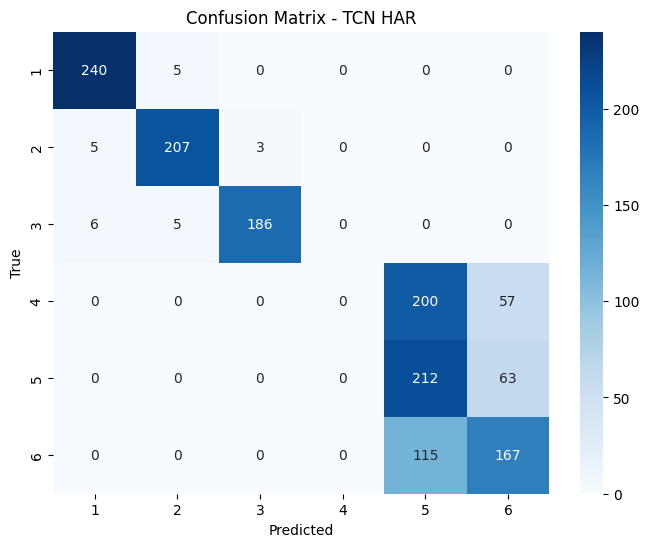

In [8]:
# Dự đoán trên tập test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# In báo cáo phân loại
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_.astype('str')))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - TCN HAR')
plt.show()

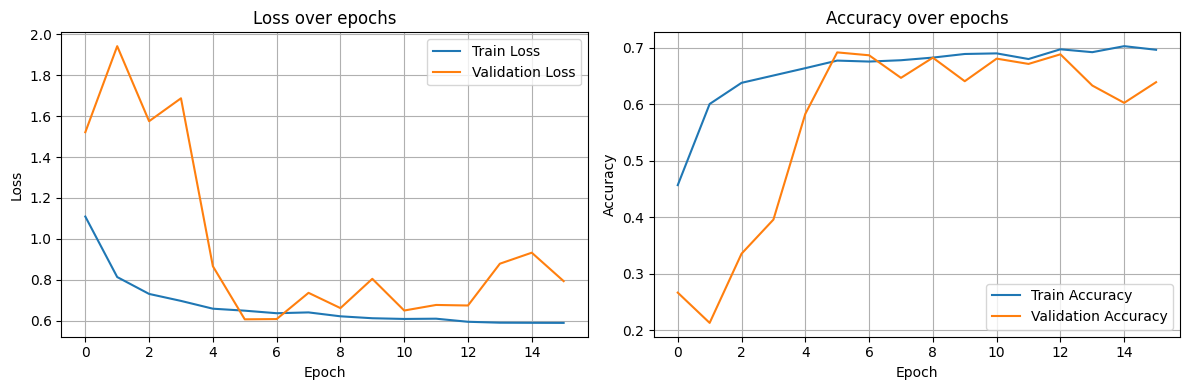

In [9]:
# Vẽ biểu đồ loss và accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()